# EDA - Exploratory Data Analysis in Python

Exploratory Data Analysis (EDA) is a important step in data analysis which focuses on understanding patterns, trends and relationships through statistical tools and visualizations. Python offers various libraries like pandas, numPy, matplotlib, seaborn and plotly which enables effective exploration and insights generation to help in further modeling and analysis. In this article, we will see how to perform EDA using python.

**Reading:** [What is Exploratory Data Analysis? - GeeksforGeeks](https://www.geeksforgeeks.org/data-analysis/what-is-exploratory-data-analysis/)

### Visualization Libraries Comparison

Python offers three main visualization libraries for EDA, each serving different purposes:

| Library | Purpose | When to Use | Key Feature |
|---------|---------|-------------|-------------|
| **Matplotlib** | Foundation plotting library | Custom plots, full control | Maximum flexibility |
| **Seaborn** | Statistical visualization | Quick statistical plots, DataFrames | Beautiful defaults |
| **Plotly** | Interactive plots | Dashboards, presentations | Hover, zoom, pan |

**Quick Tip:** Use Seaborn for quick EDA, Matplotlib for customization, and Plotly for interactive reports.

## <br>1. Importing Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr

wr.filterwarnings('ignore')

## <br>2. Reading Dataset

In [4]:
df = pd.read_csv('WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## <br>3. Analyzing the Data

`1 df.shape():` This function is used to understand the number of rows (observations) and columns (features) in the dataset. This gives an overview of the dataset's size and structure.

`2. df.info():` This function helps us to understand the dataset by showing the number of records in each column, type of data, whether any values are missing and how much memory the dataset uses.

`3. df.describe().T:` This method gives a statistical summary of the DataFrame (Transpose) showing values like count, mean, standard deviation, minimum and quartiles for each numerical column. It helps in summarizing the central tendency and spread of the data.

`4. df.columns.tolist():` This converts the column names of the DataFrame into a Python list making it easy to access and manipulate the column names.

In [ ]:
print(df.shape)
print('\n---')

df.info()
print('\n---')

df.describe().T

df.columns.tolist()

(1143, 13)

---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

---
                       count        mean         std  

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality',
 'Id']

## <br>4. Checking Missing Values
`df.isnull().sum():` This checks for missing values in each column and returns the total number of null values per column helping us to identify any gaps in our data.

In [55]:
df.isnull().sum().T

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [56]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

## <br>5. Checking for the duplicate values
`df.nunique():` This function tells us how many unique values exist in each column which provides insight into the variety of data in each feature.

In [27]:
df.nunique()

fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
dtype: int64

## <br>6. Univariate Analysis
In **Univariate** analysis plotting the right charts can help us to better understand the data making the data visualization so important.

1. Bar Plot for evaluating the count of the wine with its quality rate.

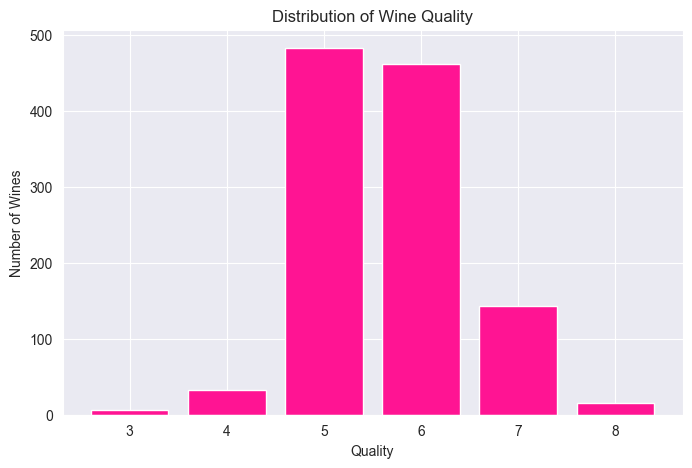

In [58]:
quality_counts = df['quality'].value_counts() # value counts is used to count the occurrences of each unique value in the 'quality' column
# print(quality_counts)

plt.figure(figsize=(8, 5))
plt.bar(quality_counts.index, quality_counts.values, color='deeppink')
plt.xlabel('Quality')
plt.ylabel('Number of Wines')
plt.title('Distribution of Wine Quality')
plt.show()

### 2. Kernel density plot for understanding variance in the dataset

`sns.set_style("darkgrid")` sets the visual theme for Seaborn plots. The "darkgrid" style provides a dark background with white grid lines, making the plots more readable and professional-looking.

`enumerate()` is a built-in Python function that adds an automatic counter to an iterable (like a list). 
- Syntax: `enumerate(iterable, start=0)`
- Example: `for i, col in enumerate(['A', 'B', 'C'], 1)` gives `(1, 'A'), (2, 'B'), (3, 'C')`

**KDE** (Kernel Density Estimation) is a smooth curve overlaid on histograms that estimates the probability density function of a continuous variable. It helps visualize the distribution shape without the choppiness of histogram bars.

**Skewness** measures how asymmetric the data distribution is:
- **0**: Perfectly symmetric (like normal distribution)
- **Positive**: Right-skewed (tail on right side, most data on left)
- **Negative**: Left-skewed (tail on left side, most data on right)

**Kurtosis** measures how heavy or light the tails of a distribution are compared to a normal distribution:
- **3**: Normal distribution
- **> 3**: Heavy tails (more extreme outliers)
- **< 3**: Light tails (fewer outliers)

```python
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(numerical_columns.__len__(), 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} | Skewness: {df[col].skew():.2f} | Kurtosis: {df[col].kurt():.2f}')
```
- **Line 1**: Loop through each numerical column, with `i` starting from 1 and `col` being the column name
- **Line 2**: Create a subplot in a grid layout (rows = number of columns, 2 columns per row, position `i`)
- **Line 3**: Draw histogram with KDE curve for the current column
- **Line 4**: Set title showing column name, its skewness value, and kurtosis value (formatted to 2 decimal places)

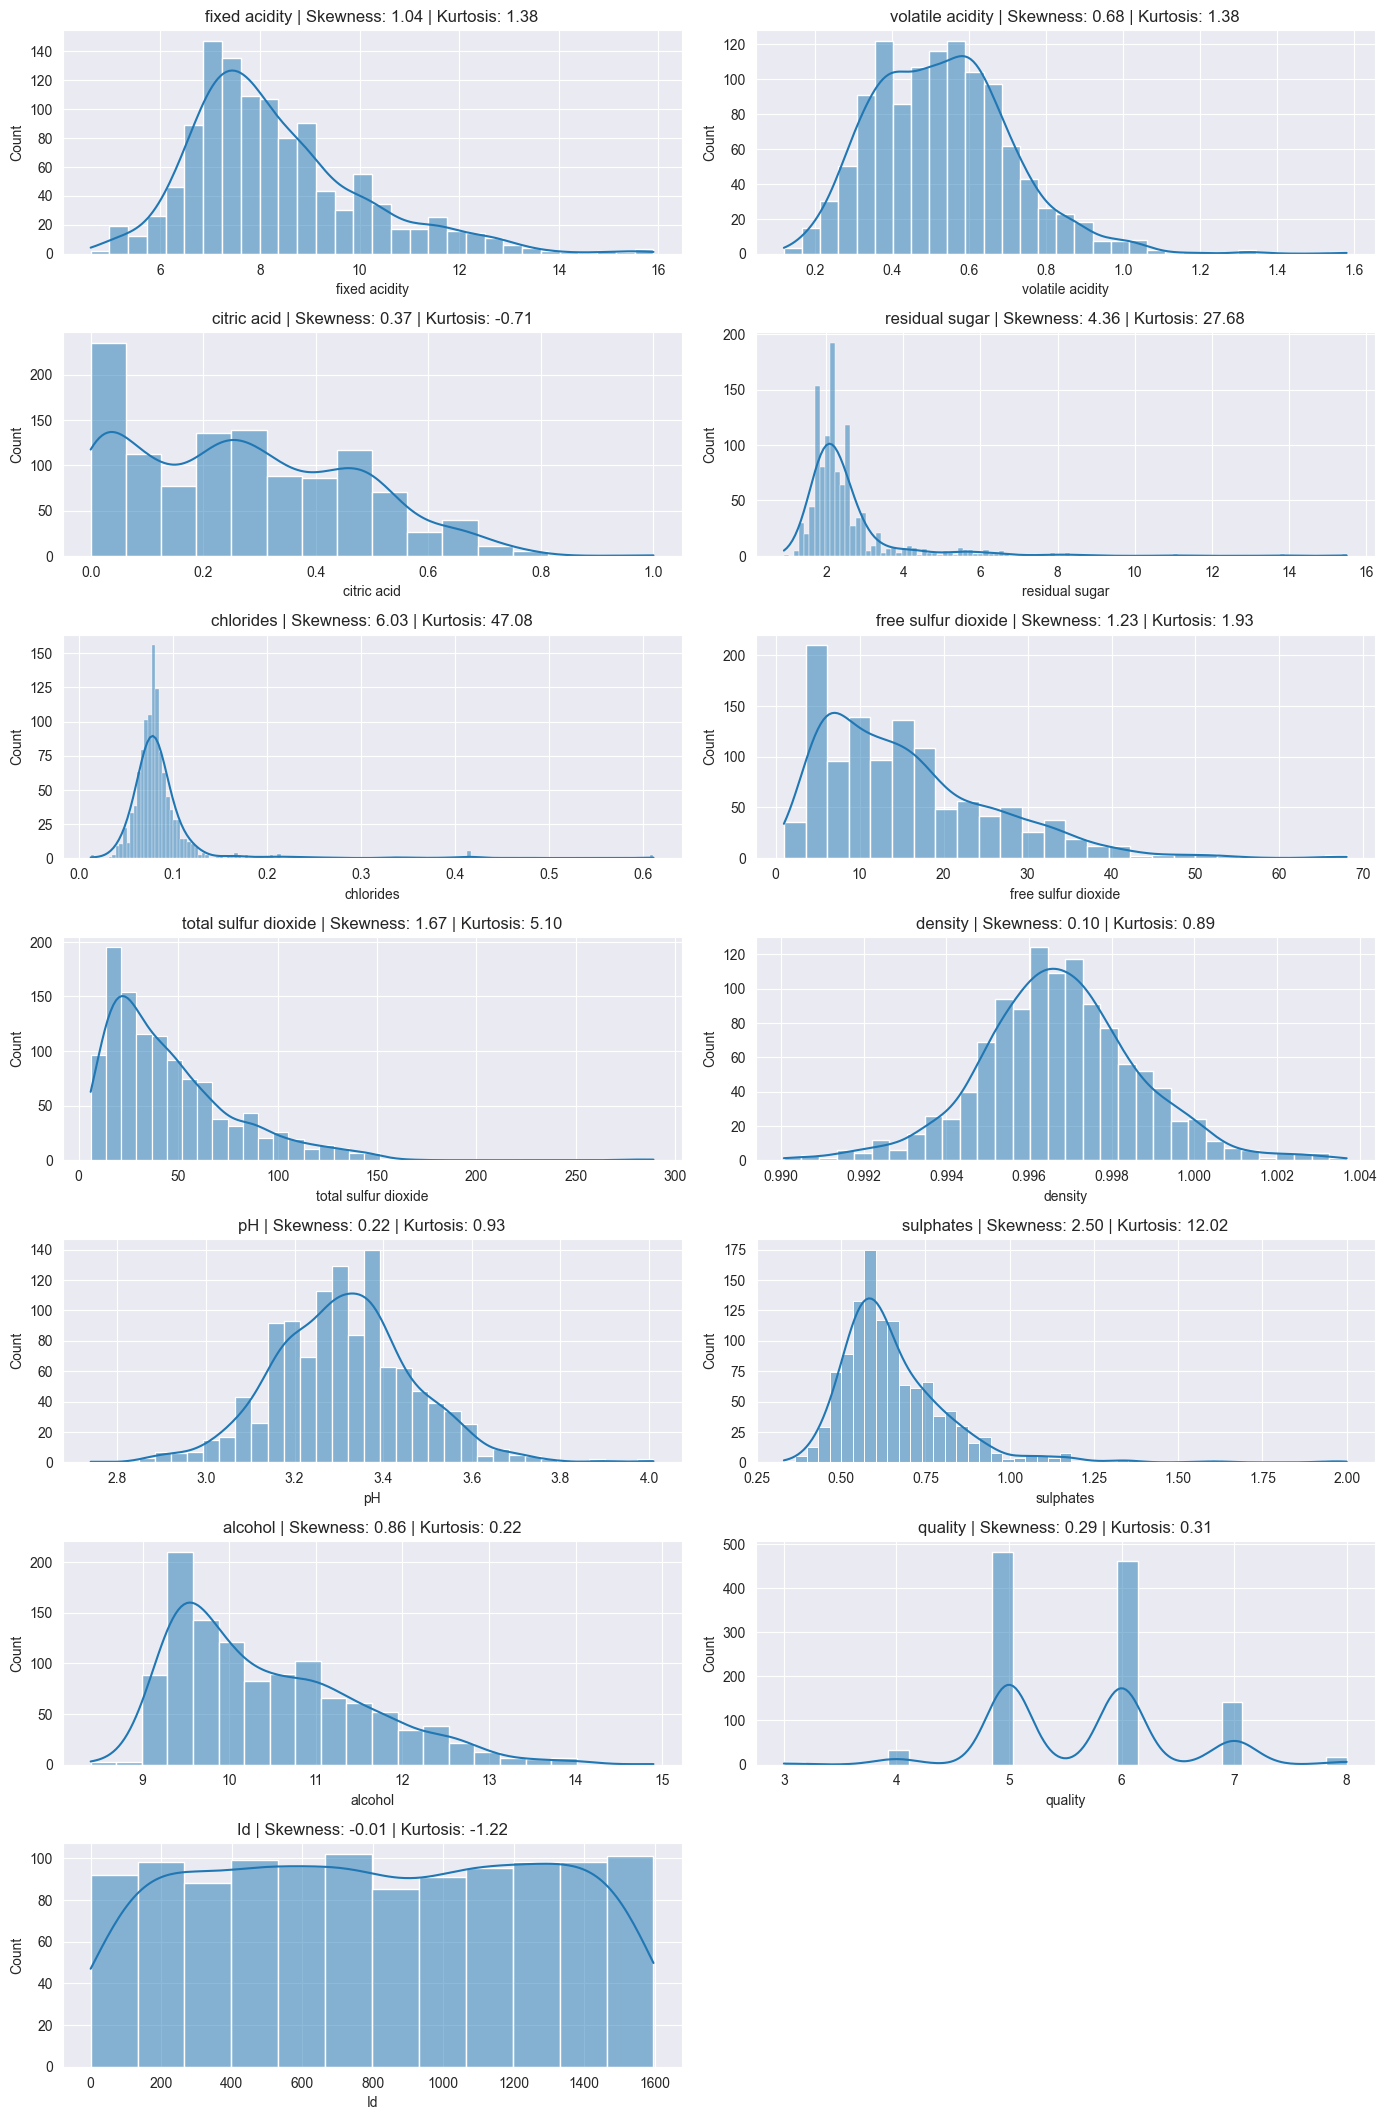

In [ ]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include=np.number).columns
# print(numerical_columns)

plt.figure(figsize=(14, numerical_columns.__len__() * 3))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(numerical_columns.__len__(), 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} | Skewness: {df[col].skew():.2f} | Kurtosis: {df[col].kurt():.2f}')

plt.tight_layout()
plt.show()

### 3. Swarm Plot for showing the outlier in the data

This graph shows the swarm plot for the 'Quality' and 'Alcohol' columns. The higher point density in certain areas shows where most of the data points are concentrated. Points that are isolated and far from these clusters represent outliers highlighting uneven values in the dataset.

**Key Interpretation Points:**

- **Density & Frequency:** Where points bunch up (the "swarm" effect), there's a high concentration of data at that value for that category. Wider sections mean more data points.

- **Distribution:** The overall spread of points shows the range and distribution (e.g., skewed, clustered) of numerical values within each category.

- **Comparison:** Easily compare data distributions between different categories (e.g., "Ideal" vs. "Premium" diamond cuts).

- **Outliers:** Isolated points far from the main swarm are potential outliers.

- **Feature Importance (SHAP):** In machine learning, a SHAP swarm plot shows how much a feature influences predictions; points colored by SHAP value (red for high, blue for low) reveal if high feature values push predictions high or low.


Text(0.5, 1.0, 'Alcohol Content by Wine Quality')

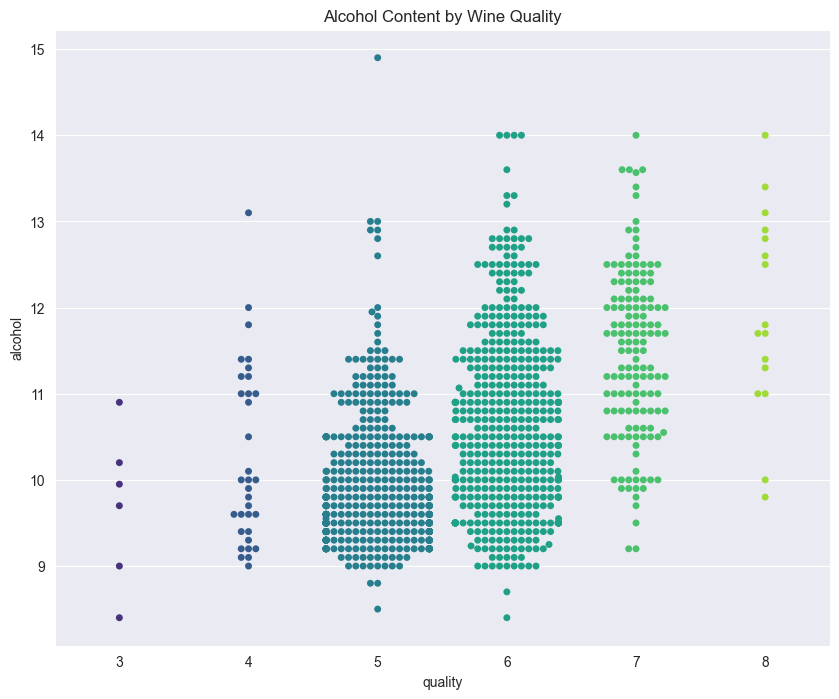

In [ ]:
plt.figure(figsize=(10, 8))

sns.swarmplot(x='quality', y='alcohol', data=df, palette='viridis')
plt.title('Alcohol Content by Wine Quality')
# plt.xlabel('Quality')
# plt.ylabel('Alcohol Content')
# plt.show()